In [73]:
# importing librarys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,Lasso,Ridge,LogisticRegression
from sklearn.metrics import r2_score,mean_squared_error,accuracy_score,confusion_matrix,precision_score,classification_report
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder,StandardScaler


# Understanding Data

In [74]:
df=pd.read_csv("bank.csv")
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no


In [75]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [76]:
df.shape

(11162, 17)

In [77]:
df.isnull().sum().sum()

0

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [79]:
df.describe(include="all").transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,11162.0,NaN,NaN,NaN,41.231948,11.913369,18.0,32.0,39.0,49.0,95.0
job,11162,12,management,2566,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,11162,3,married,6351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,11162,4,secondary,5476,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,11162,2,no,10994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
balance,11162.0,NaN,NaN,NaN,1528.538524,3225.413326,-6847.0,122.0,550.0,1708.0,81204.0
housing,11162,2,no,5881,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,11162,2,no,9702,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,11162,3,cellular,8042,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,11162.0,NaN,NaN,NaN,15.658036,8.42074,1.0,8.0,15.0,22.0,31.0


In [80]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [81]:
df['contact'].nunique()

3

In [82]:
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no


In [83]:
categorical_column=df.select_dtypes(include=["object","category"]).columns.tolist()
for feature in categorical_column:
   print(feature)

job
marital
education
default
housing
loan
contact
month
poutcome
deposit


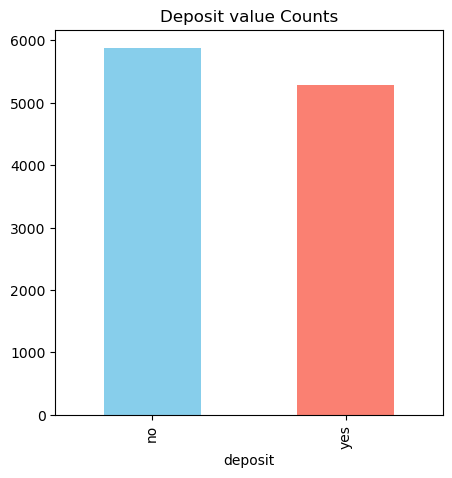

In [84]:
df['deposit'].value_counts().plot.bar(figsize=(5,5),title='Deposit value Counts',color=['skyblue', 'salmon'])
plt.show()

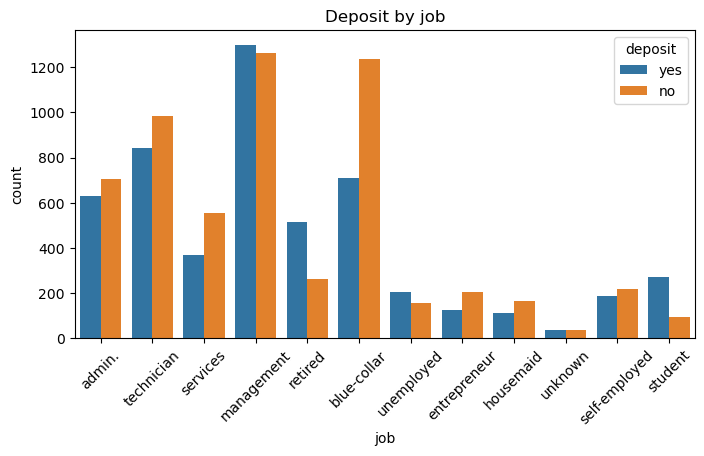

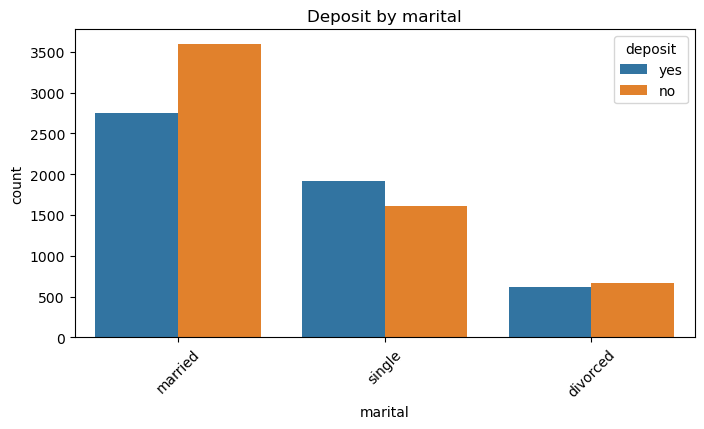

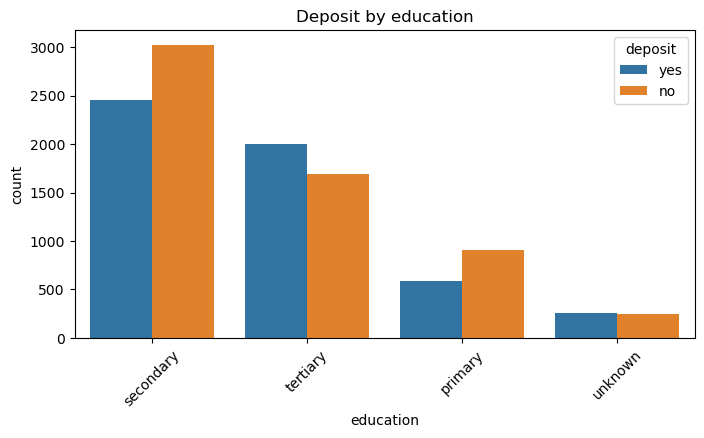

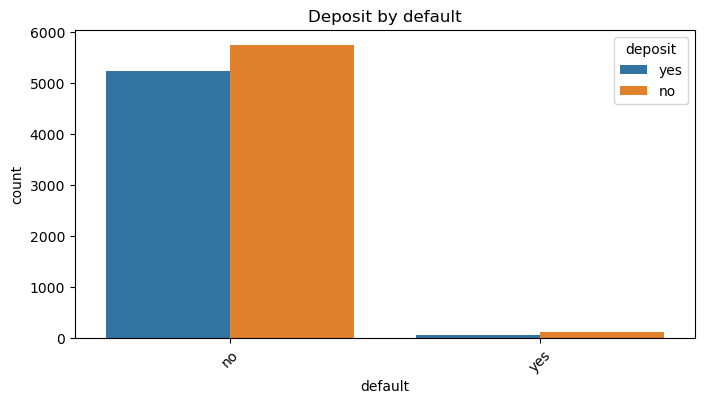

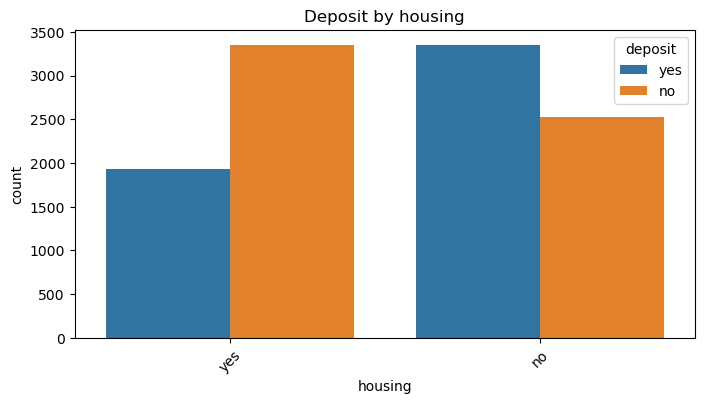

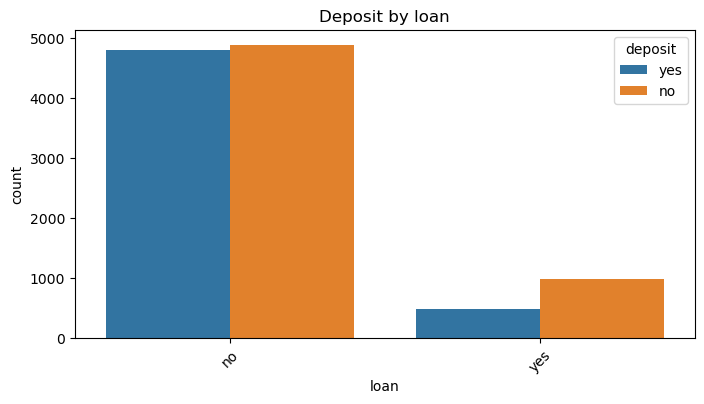

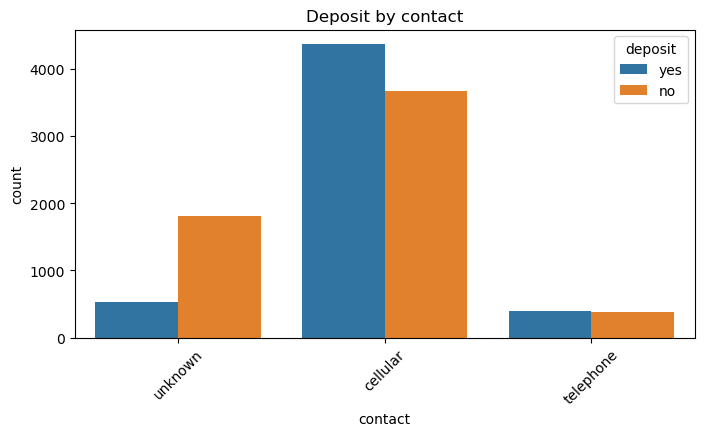

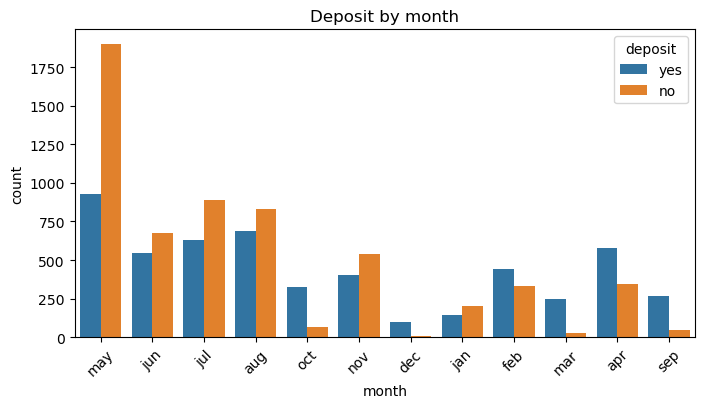

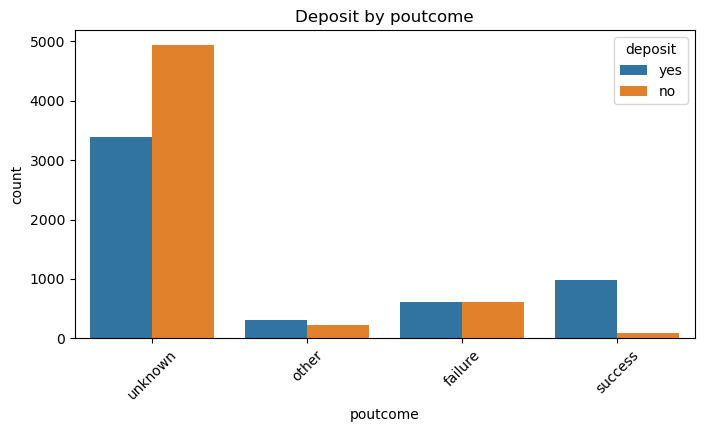

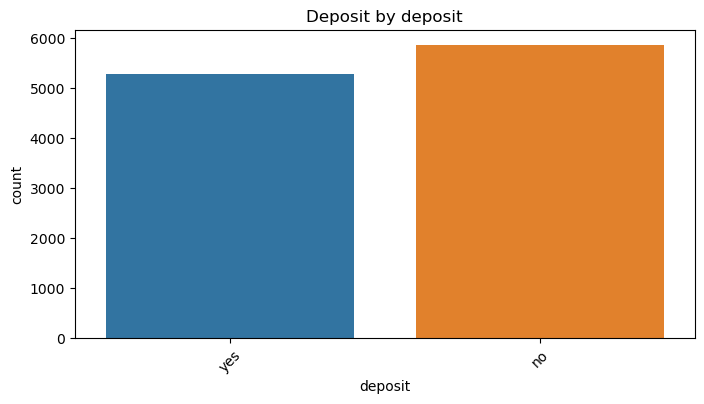

In [85]:
cat_cols = df.select_dtypes(exclude=['int64', 'float64'])
for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col, hue='deposit')
    plt.xticks(rotation=45)
    plt.title(f'Deposit by {col}')
    plt.show()

In [86]:
df['previous'].nunique()

34

In [87]:
df['education'].unique()

array(['secondary', 'tertiary', 'primary', 'unknown'], dtype=object)

## Encoding

In [88]:
df['education'] = df['education'].map({'primary':0,'secondary' :1,'tertiary' :2,'unknown':3 })
display(df.head())

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,1,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,1,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,1,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,1,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,2,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [89]:
df['job'].unique()

array(['admin.', 'technician', 'services', 'management', 'retired',
       'blue-collar', 'unemployed', 'entrepreneur', 'housemaid',
       'unknown', 'self-employed', 'student'], dtype=object)

In [90]:
df['poutcome'].unique()

array(['unknown', 'other', 'failure', 'success'], dtype=object)

In [91]:
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,1,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,1,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,1,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,1,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,2,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,0,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,1,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,1,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,1,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no


In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  int64 
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(8), object(9)
memory usage: 1.4+ MB


### label encoding

In [93]:
le=LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
  df[col]=le.fit_transform(df[col])

## Finding correlation

In [94]:
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,0,1,1,0,2343,1,0,2,5,8,1042,1,-1,0,3,1
1,56,0,1,1,0,45,0,0,2,5,8,1467,1,-1,0,3,1
2,41,9,1,1,0,1270,1,0,2,5,8,1389,1,-1,0,3,1
3,55,7,1,1,0,2476,1,0,2,5,8,579,1,-1,0,3,1
4,54,0,1,2,0,184,0,0,2,5,8,673,2,-1,0,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,1,2,0,0,1,1,0,0,20,0,257,1,-1,0,3,0
11158,39,7,1,1,0,733,0,0,2,16,6,83,4,-1,0,3,0
11159,32,9,2,1,0,29,0,0,0,19,1,156,2,-1,0,3,0
11160,43,9,1,1,0,0,0,1,0,8,8,9,2,172,5,0,0


In [95]:
df.corr()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
age,1.000000,-0.031603,-0.442782,-0.126018,-0.011425,0.112300,-0.168700,-0.031418,0.027762,-0.000762,-0.026130,0.000189,-0.005278,0.002774,0.020169,-0.002699,0.034901
job,-0.031603,1.000000,0.078314,0.147046,-0.007066,0.028736,-0.136965,-0.067092,-0.087915,0.026589,-0.076011,0.002432,0.003104,-0.003385,0.012665,-0.004238,0.063395
marital,-0.442782,0.078314,1.000000,0.125845,-0.014691,-0.002138,-0.036345,-0.062029,-0.060456,-0.003642,-0.004070,0.006781,-0.030794,0.031200,0.031281,-0.039424,0.067610
education,-0.126018,0.147046,0.125845,1.000000,-0.010709,0.051728,-0.109168,-0.073154,-0.132540,0.016759,-0.055868,-0.019122,-0.005327,0.025165,0.022427,-0.040262,0.095948
default,-0.011425,-0.007066,-0.014691,-0.010709,1.000000,-0.060954,0.011076,0.076434,0.035709,0.017342,0.000950,-0.009760,0.030975,-0.036282,-0.035273,0.042357,-0.040680
balance,0.112300,0.028736,-0.002138,0.051728,-0.060954,1.000000,-0.077092,-0.084589,-0.027295,0.010467,0.007264,0.022436,-0.013894,0.017411,0.030805,-0.027151,0.081129
housing,-0.168700,-0.136965,-0.036345,-0.109168,0.011076,-0.077092,1.000000,0.076761,0.226392,-0.014770,0.219602,0.035051,0.006660,0.064497,-0.000840,-0.046370,-0.203888
loan,-0.031418,-0.067092,-0.062029,-0.073154,0.076434,-0.084589,0.076761,1.000000,0.006829,0.017269,0.025329,-0.001914,0.034722,-0.030416,-0.022668,0.026344,-0.110580
contact,0.027762,-0.087915,-0.060456,-0.132540,0.035709,-0.027295,0.226392,0.006829,1.000000,0.007943,0.289803,-0.018000,0.059258,-0.227785,-0.169919,0.257993,-0.249847
day,-0.000762,0.026589,-0.003642,0.016759,0.017342,0.010467,-0.014770,0.017269,0.007943,1.000000,-0.019840,-0.018511,0.137007,-0.077232,-0.058981,0.080221,-0.056326


<Axes: >

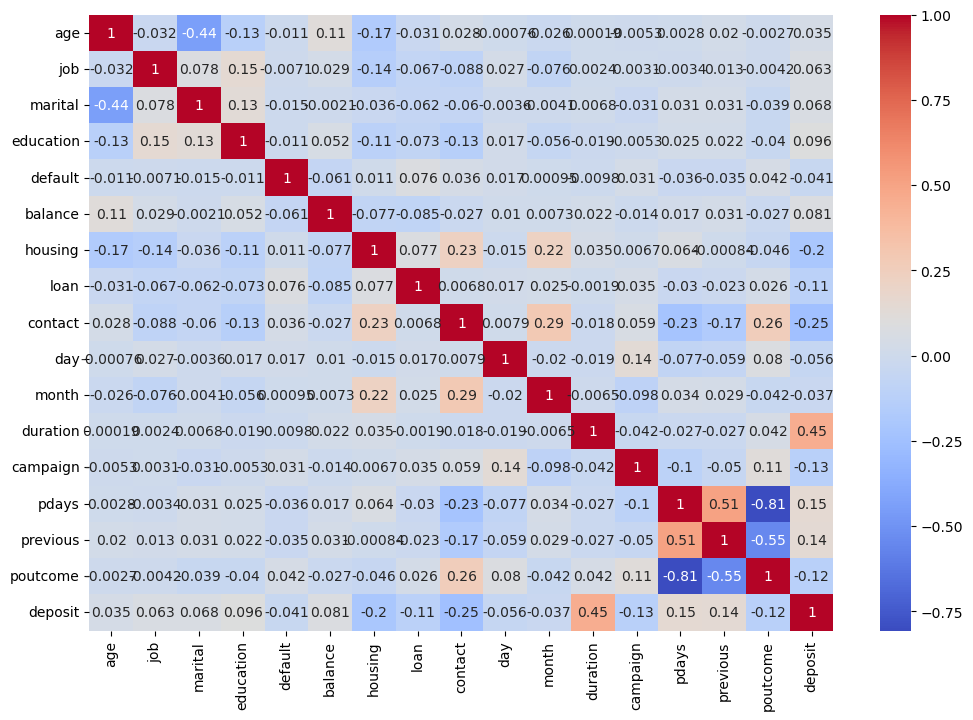

In [96]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')

# Removing multi corelated features

In [97]:
df.drop(columns='previous',inplace=True)

In [98]:
df.drop(columns='pdays',inplace=True)

In [99]:
df.drop(columns="contact",inplace=True)

In [100]:
df.drop(columns="day",inplace=True)

<Axes: >

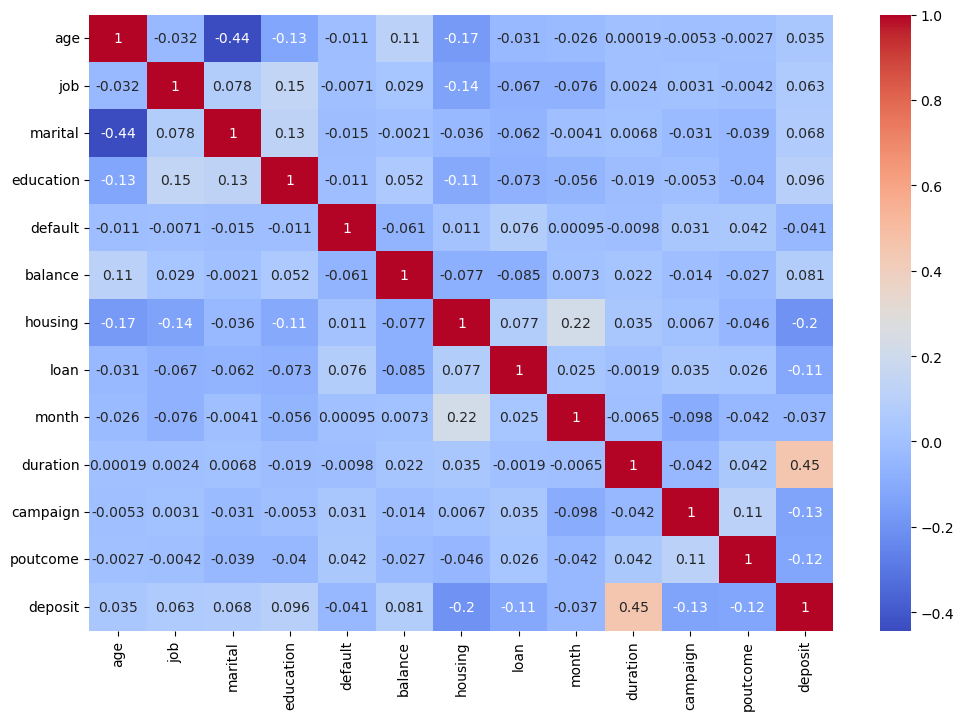

In [101]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')

In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        11162 non-null  int64
 1   job        11162 non-null  int32
 2   marital    11162 non-null  int32
 3   education  11162 non-null  int64
 4   default    11162 non-null  int32
 5   balance    11162 non-null  int64
 6   housing    11162 non-null  int32
 7   loan       11162 non-null  int32
 8   month      11162 non-null  int32
 9   duration   11162 non-null  int64
 10  campaign   11162 non-null  int64
 11  poutcome   11162 non-null  int32
 12  deposit    11162 non-null  int32
dtypes: int32(8), int64(5)
memory usage: 785.0 KB


## Data Transformation

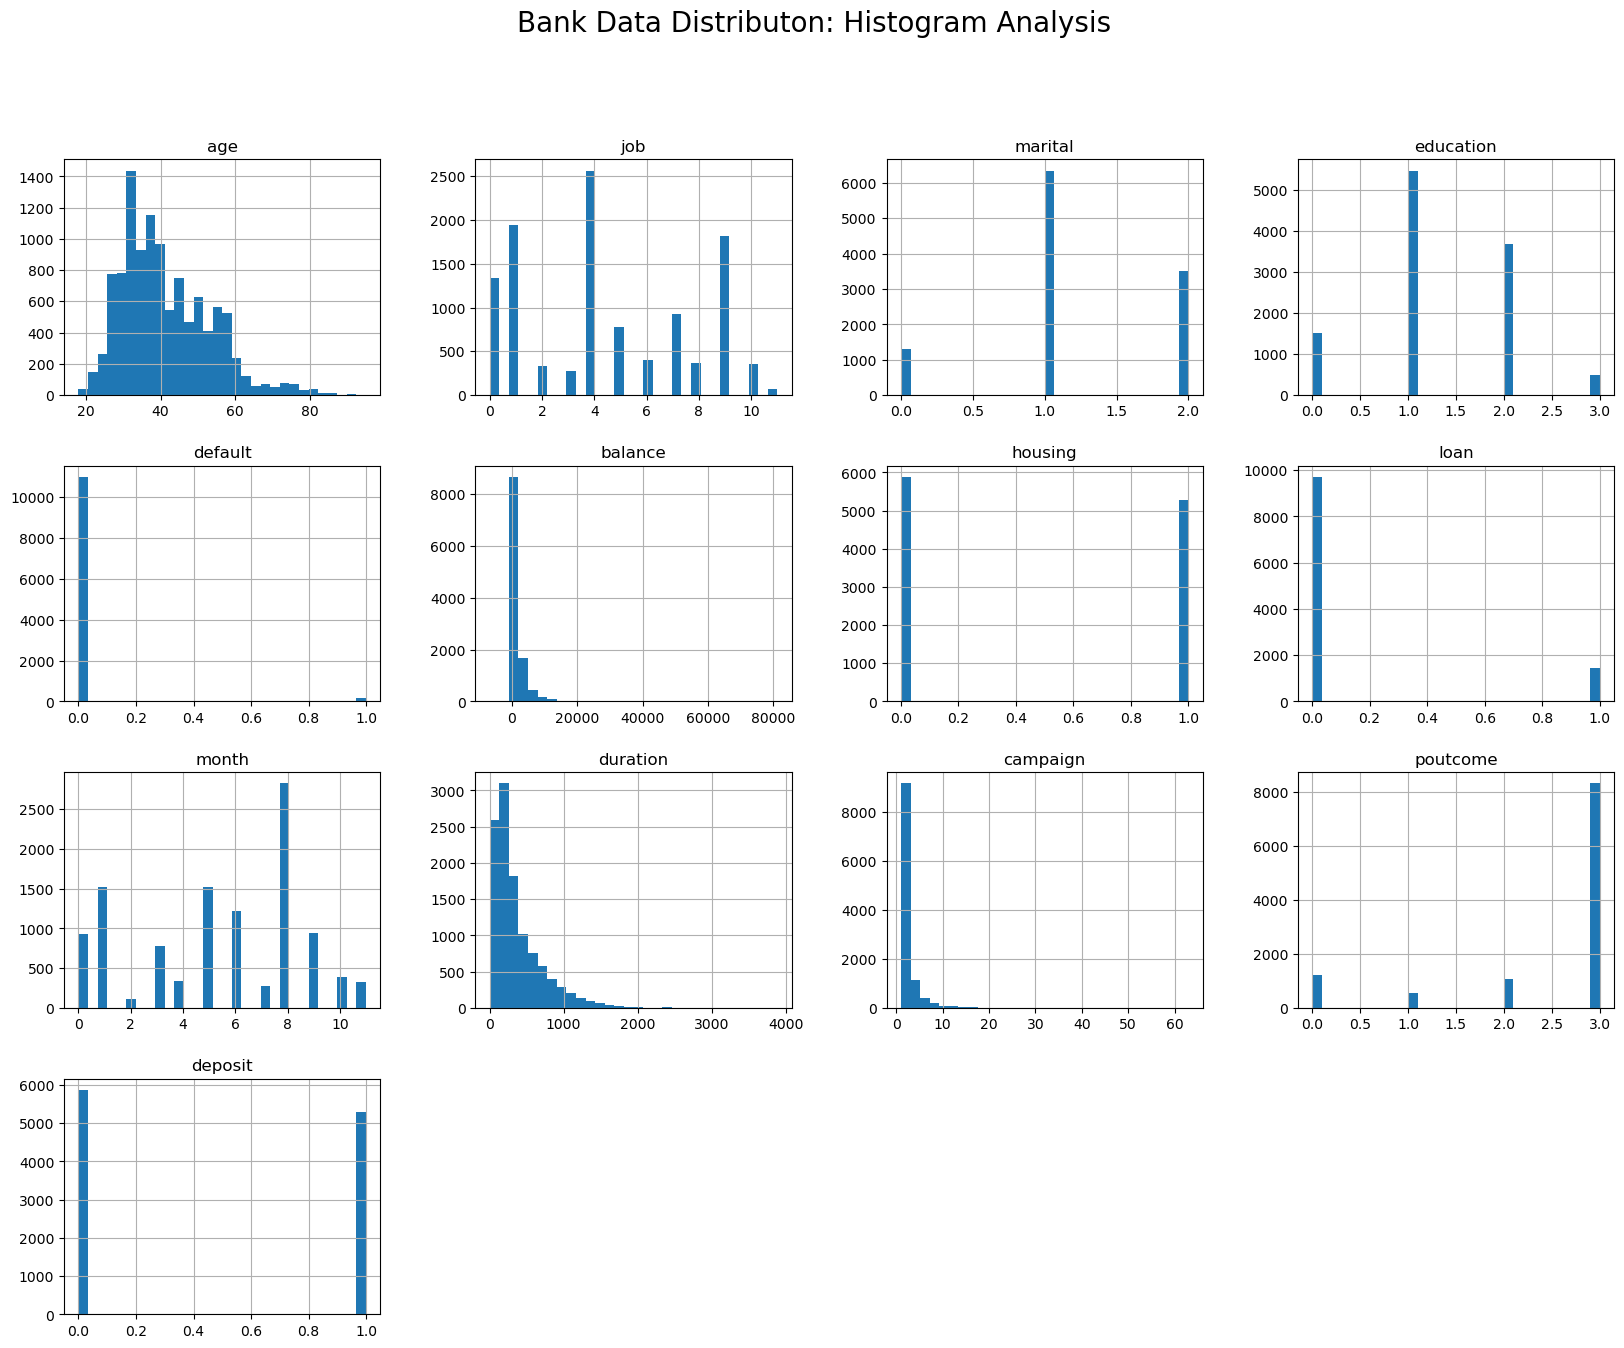

In [103]:
df.hist(bins=30,figsize=(20,15))
plt.suptitle("Bank Data Distributon: Histogram Analysis",fontsize=20)
plt.show()


In [104]:
skewness=df.skew()
skewness

age          0.862780
job          0.184306
marital     -0.173968
education    0.115543
default      7.966983
balance      8.224619
housing      0.107678
loan         2.190201
month       -0.322998
duration     2.143695
campaign     5.545578
poutcome    -1.718276
deposit      0.104798
dtype: float64

In [105]:
df_copy=df.copy()

#log Transformation of skewed columns (eg., AnnualIncome, LoanAmount)
df['duration']=np.log1p(df['duration']) # LOG(1 + X) TO handle skew
df['campaign']=np.log1p(df['campaign'])
#df['balance']=np.log1p(df['balance'])   #have negative values

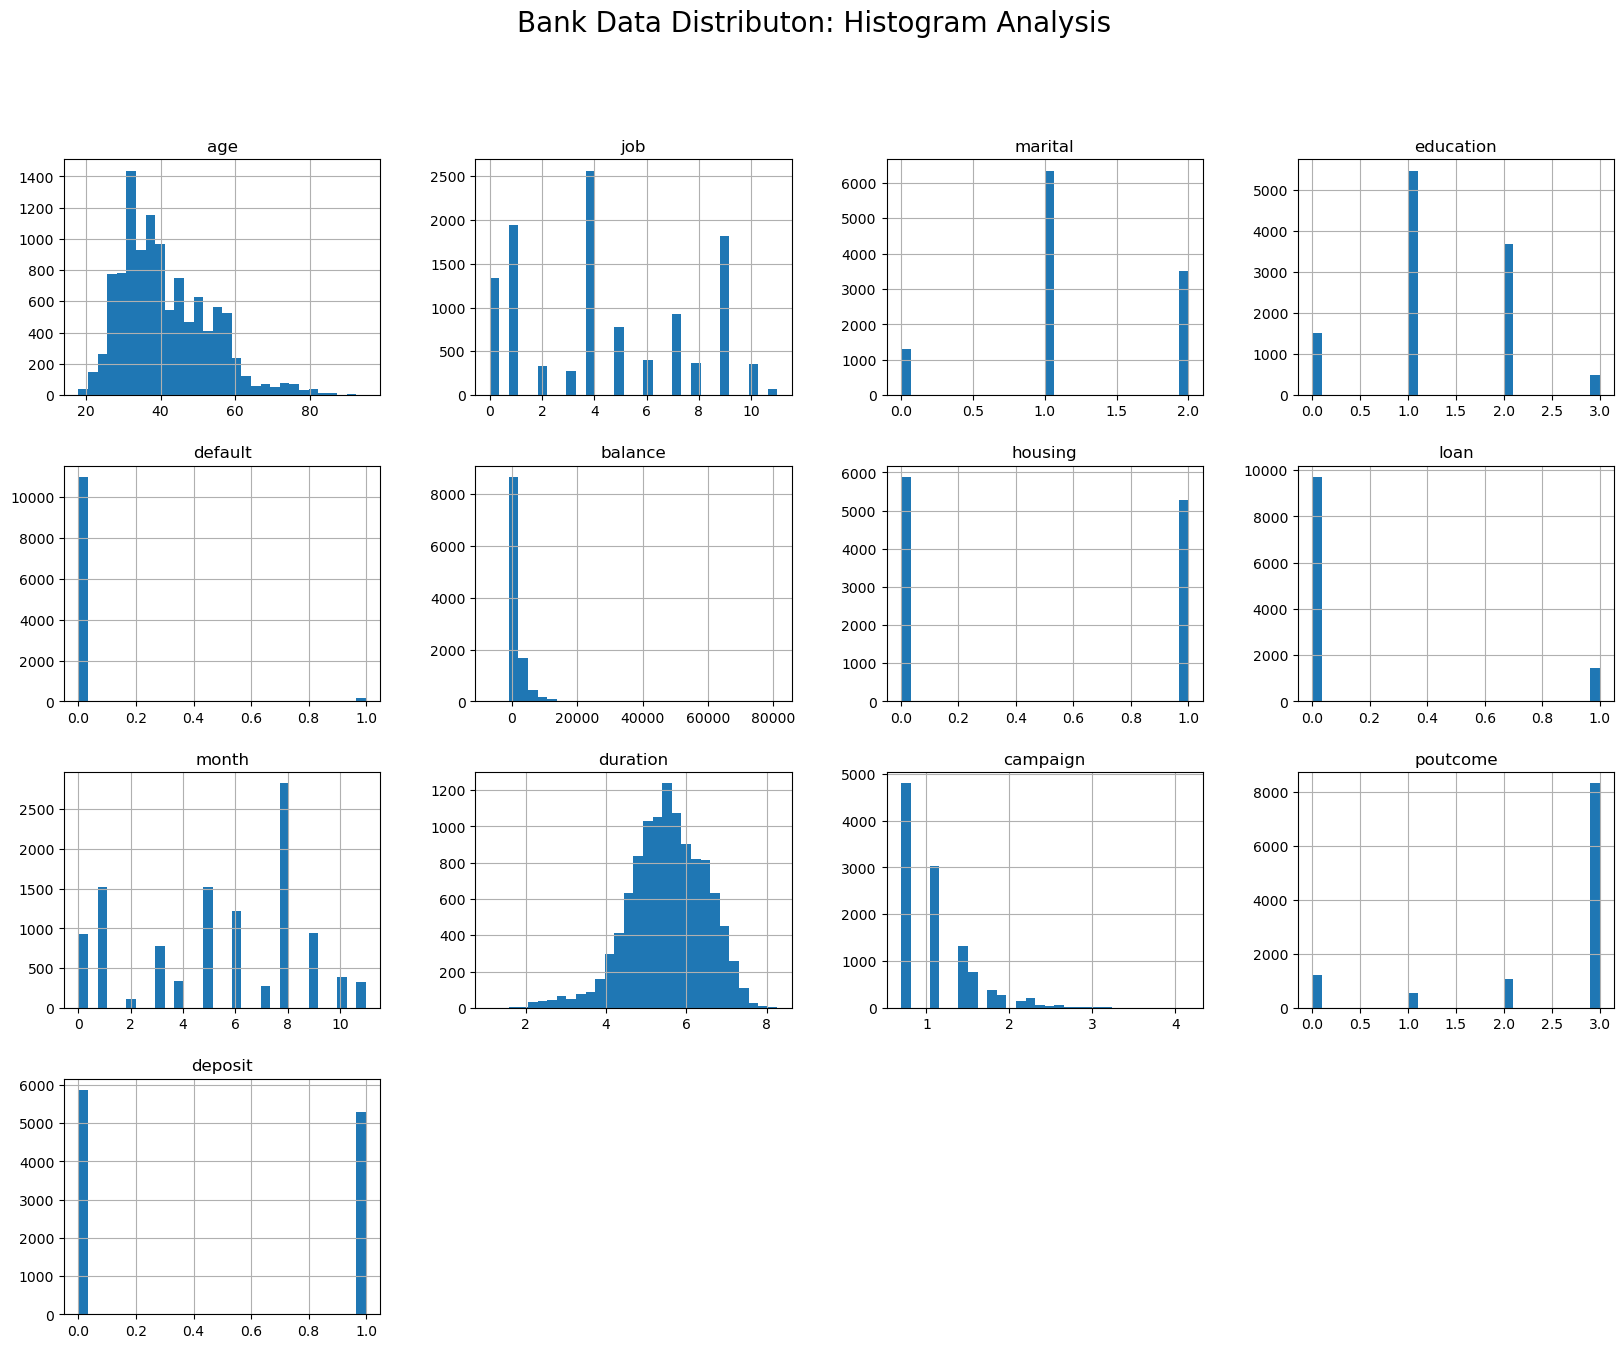

In [106]:
df.hist(bins=30,figsize=(20,15))
plt.suptitle("Bank Data Distributon: Histogram Analysis",fontsize=20)
plt.show()

## Skewness handeling

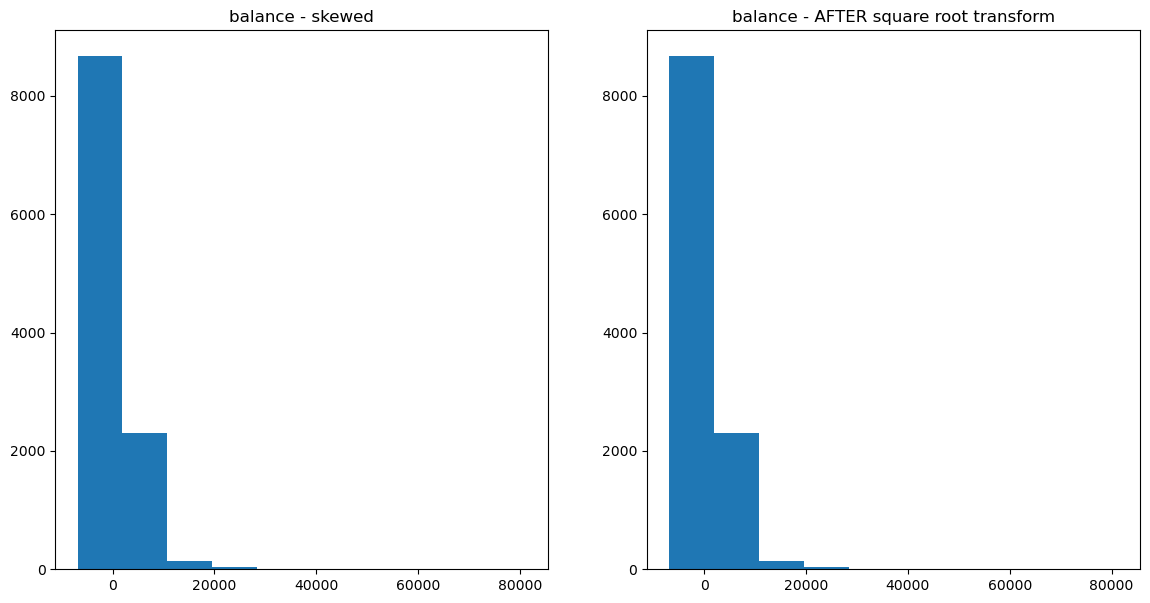

In [107]:
plt.figure(figsize=(14,7))


ax1=plt.subplot(1,2,1)
cp=plt.hist(df_copy['balance'])
plt.title("balance - skewed")

ax2=plt.subplot(1,2,2)
plt.hist(df['balance'])
plt.title('balance - AFTER square root transform')
plt.show()

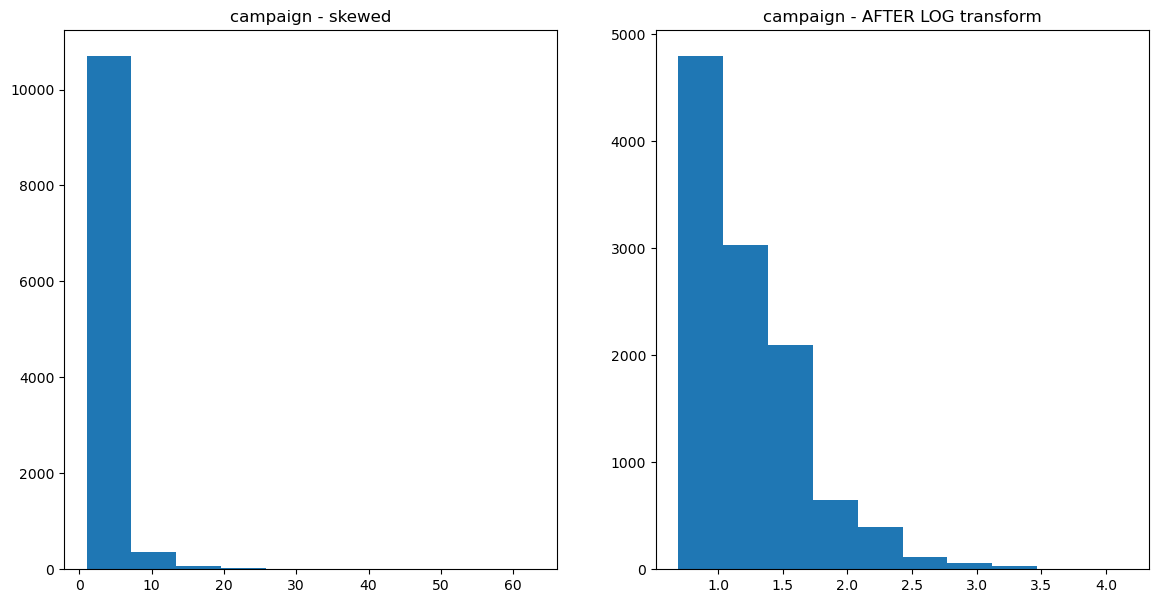

In [108]:
plt.figure(figsize=(14,7))


ax1=plt.subplot(1,2,1)
cp=plt.hist(df_copy['campaign'])
plt.title("campaign - skewed")

ax2=plt.subplot(1,2,2)
plt.hist(df['campaign'])
plt.title('campaign - AFTER LOG transform')
plt.show()

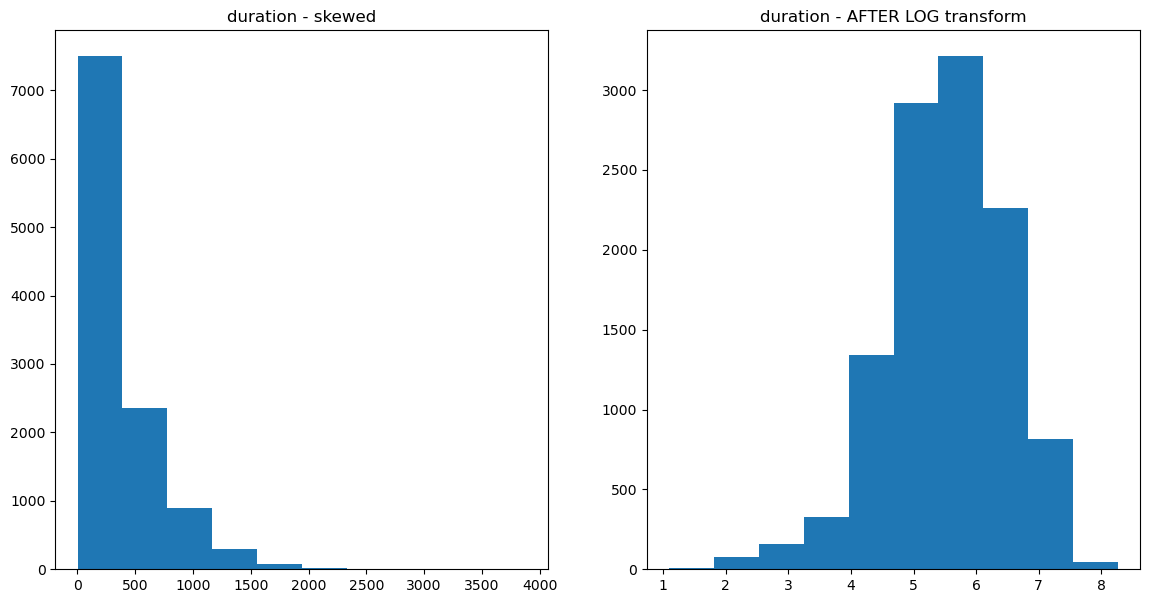

In [109]:
plt.figure(figsize=(14,7))


ax1=plt.subplot(1,2,1)
cp=plt.hist(df_copy['duration'])
plt.title("duration - skewed")

ax2=plt.subplot(1,2,2)
plt.hist(df['duration'])
plt.title('duration - AFTER LOG transform')
plt.show()

In [110]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
month        0
duration     0
campaign     0
poutcome     0
deposit      0
dtype: int64

In [111]:
df['balance']=df['balance'].fillna(df['balance'].mean())

In [112]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
month        0
duration     0
campaign     0
poutcome     0
deposit      0
dtype: int64

## Spliting data

In [113]:
x=df.drop(columns="deposit")
y=df["deposit"]

In [114]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

## Scaling

In [115]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

## Handling outliers

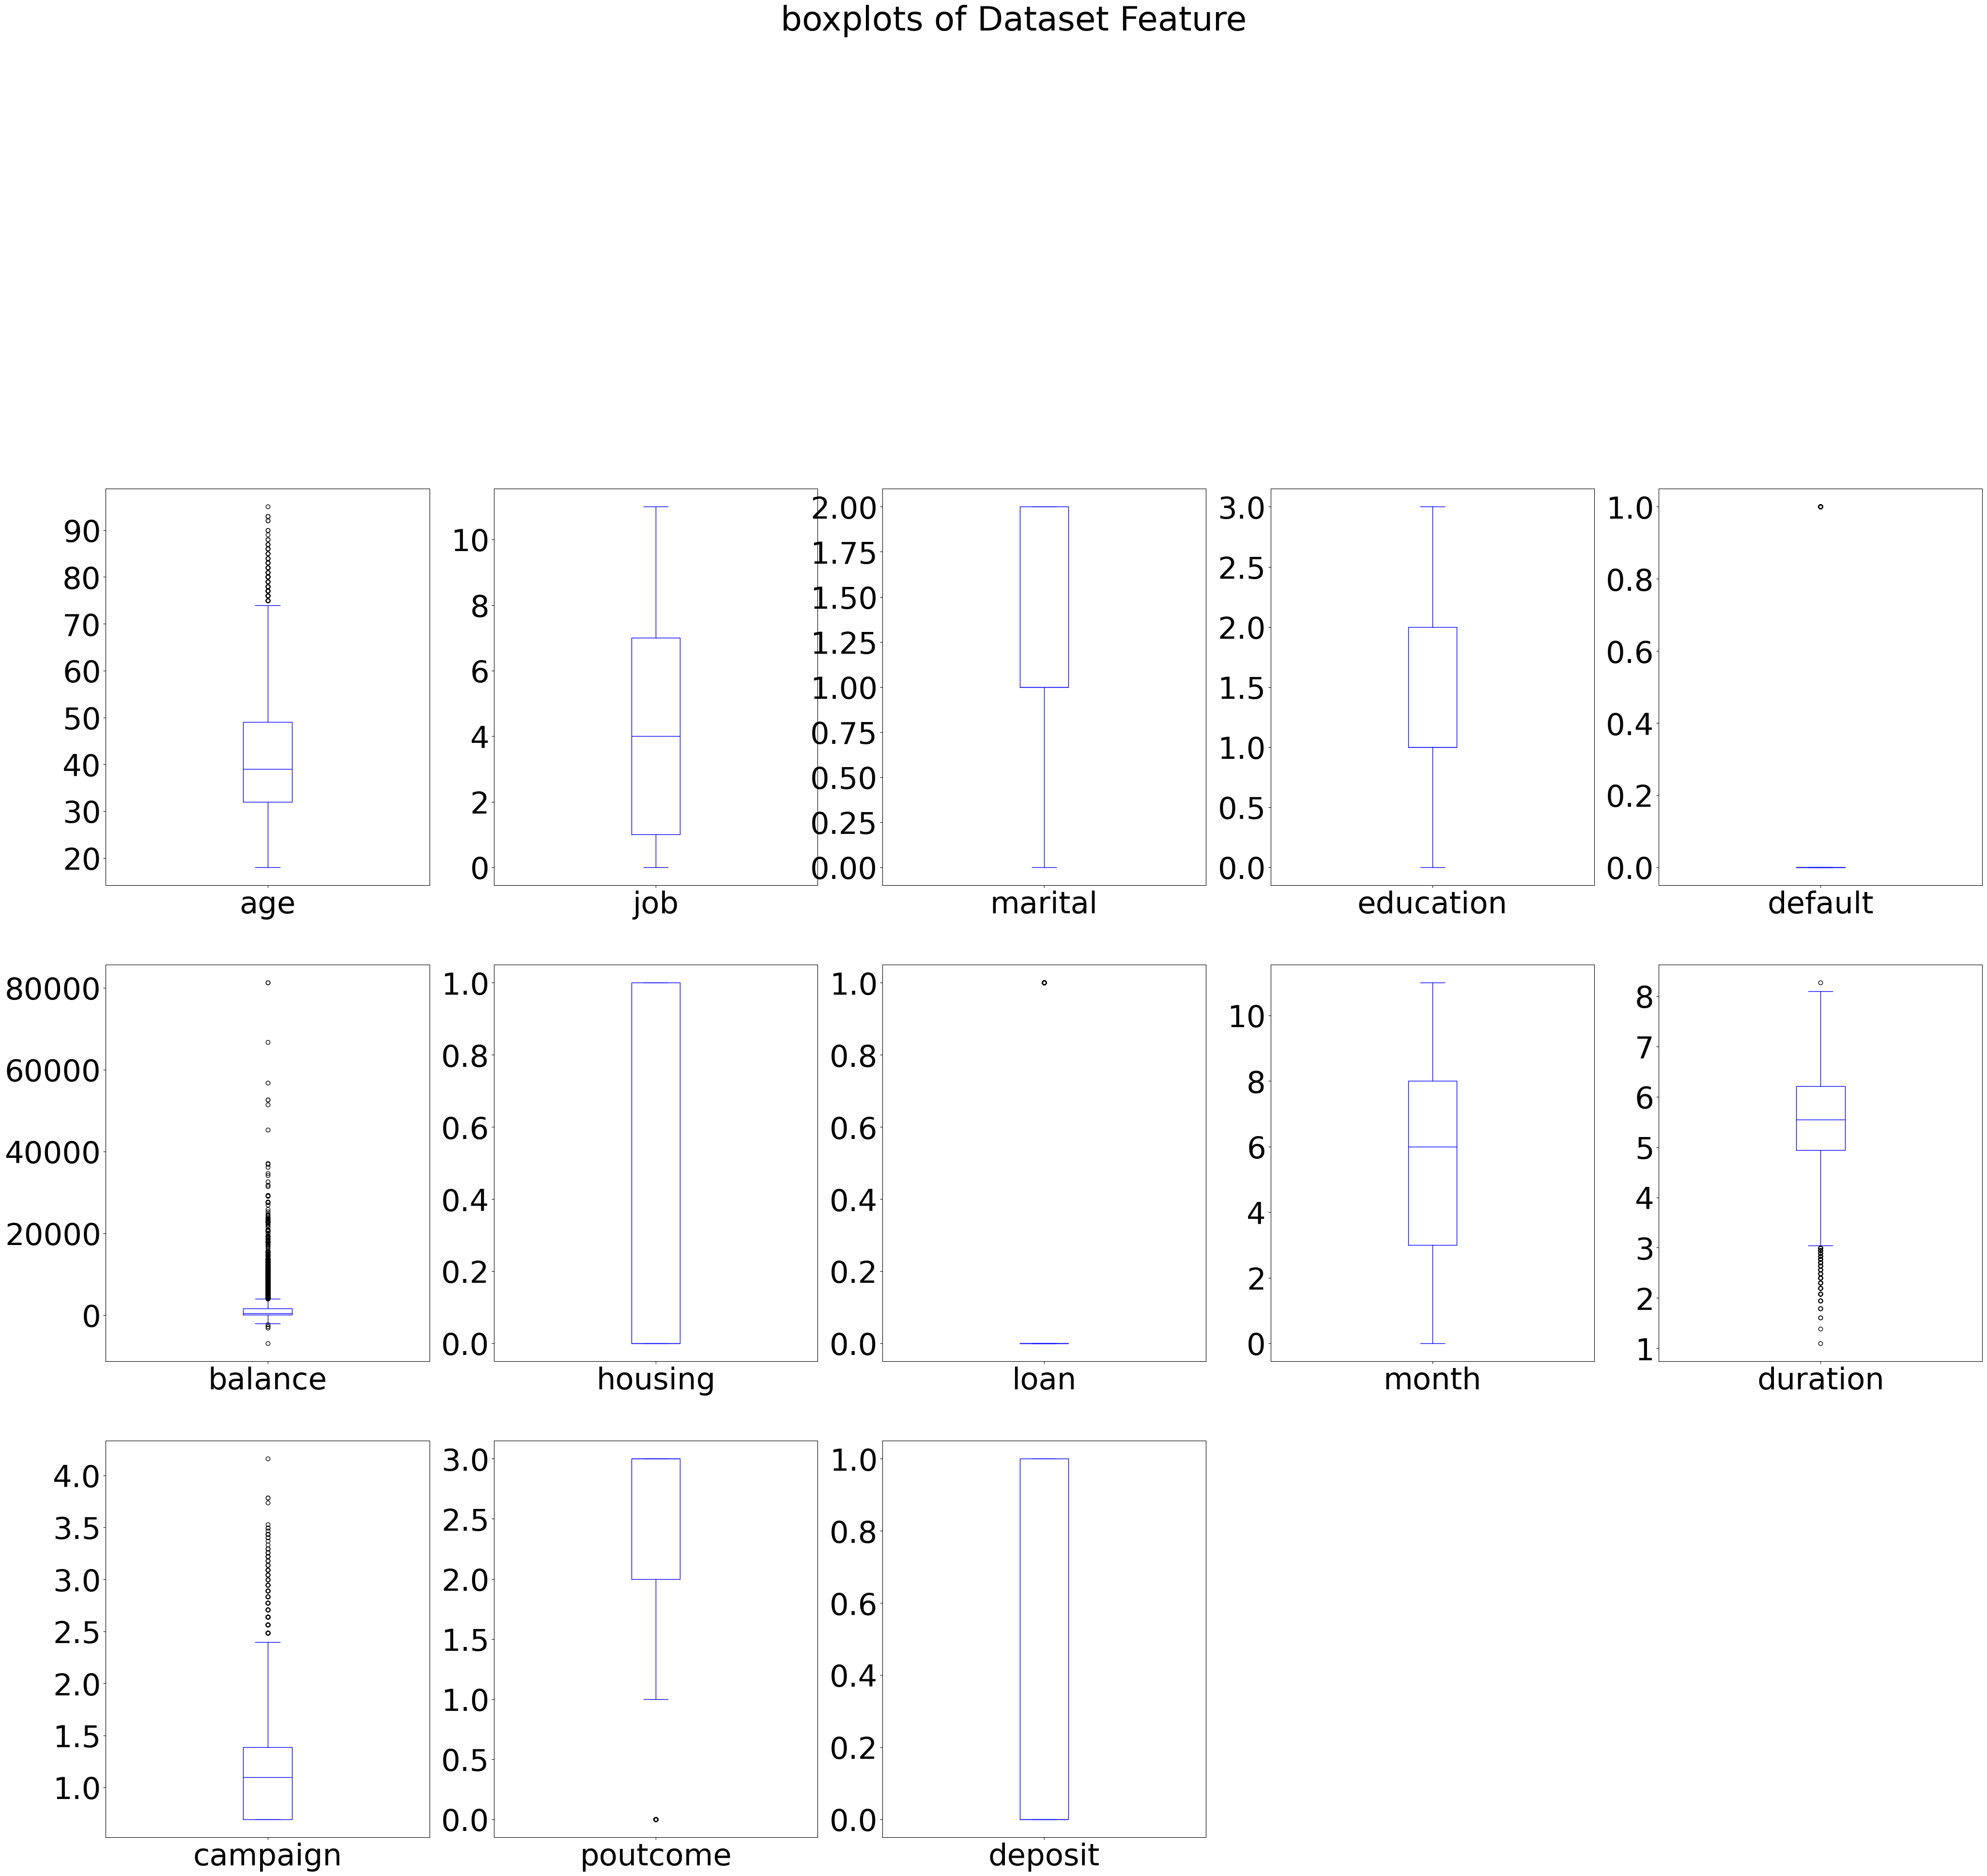

In [116]:
df.plot(kind='box',subplots=True,layout=(8,5),figsize=(50,100),color='blue',fontsize=45)

plt.suptitle("boxplots of Dataset Feature",fontsize=50)
plt.show()

In [117]:
#Creat  a copy of the orginal data for comparison
scaled_df=df.copy()

def remove_outliers_iqr(df,exclude_columns):
    #Loop through numeric colums
    for column in df.select_dtypes(include=['number']):
        if column in exclude_columns:
            continue #skip exclude columns

        Q1=df[column].quantile(0.25)
        Q3=df[column].quantile(0.75)
        IQR = Q3 -Q1

        #Define outlire bounds
        lower_bound=Q1 -1.5 *IQR
        upper_bound=Q3 + 1.5 *IQR

        #Filter out the outliers
        df=df[(df[column]>= lower_bound)& (df[column]<=upper_bound)]

    return df

#Define the columns to exclude
exclude_columns=['','','']

#Remove outlier
df= remove_outliers_iqr(df, exclude_columns)

#print shapes of data before and after removing outliers
print('Shape of Data before removing outlies:',df_copy.shape)
print('Shape of Data after removing outlies:',df.shape)
print('Number of outliers removed:', df_copy.shape[0]-df.shape[0])

Shape of Data before removing outlies: (11162, 13)
Shape of Data after removing outlies: (7276, 13)
Number of outliers removed: 3886


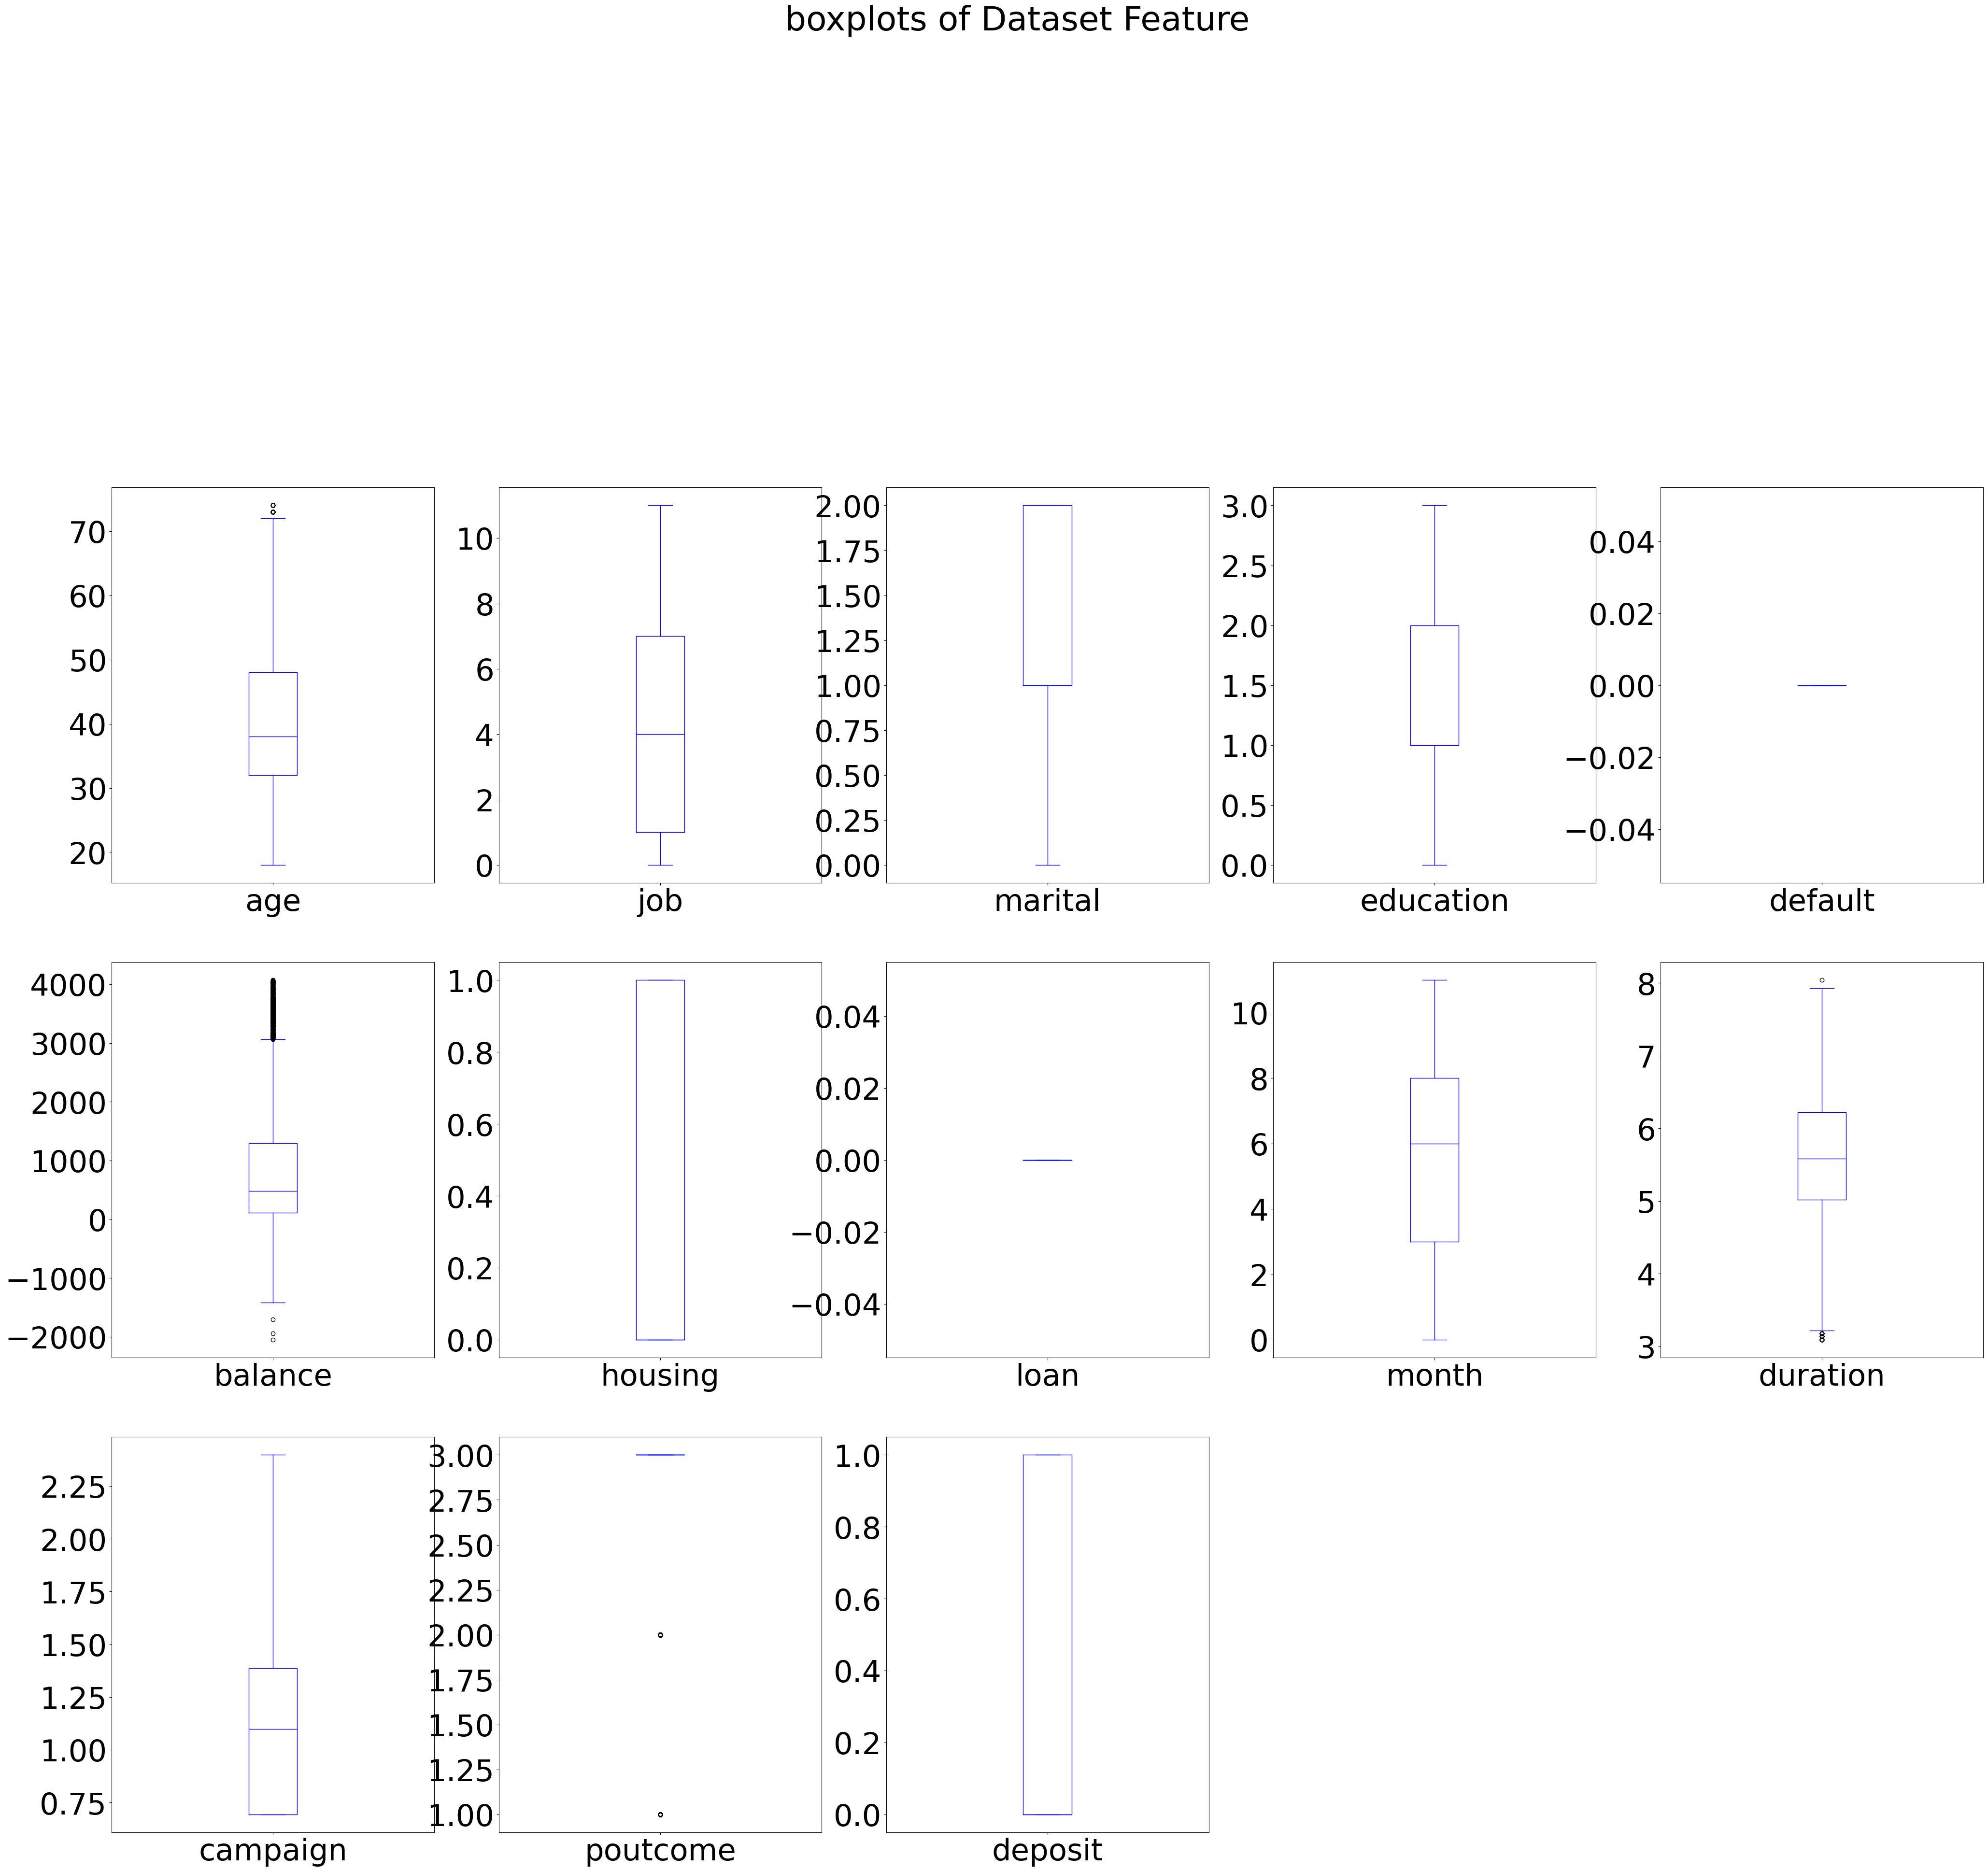

In [118]:
df.plot(kind='box',subplots=True,layout=(8,5),figsize=(50,100),color='blue',fontsize=45)

plt.suptitle("boxplots of Dataset Feature",fontsize=50)
plt.show()

## Model selection

In [119]:
model=LogisticRegression()
model.fit(x_train,y_train)

LogisticRegression()

In [120]:
y_pred=model.predict(x_test)

In [121]:
print("accuracy score:\n",accuracy_score(y_test,y_pred))
print("confusion matrix:\n",confusion_matrix(y_test,y_pred))
print("classification report:\n",classification_report(y_test,y_pred))

accuracy score:
 0.7711598746081505
confusion matrix:
 [[898 268]
 [243 824]]
classification report:
               precision    recall  f1-score   support

           0       0.79      0.77      0.78      1166
           1       0.75      0.77      0.76      1067

    accuracy                           0.77      2233
   macro avg       0.77      0.77      0.77      2233
weighted avg       0.77      0.77      0.77      2233



In [122]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7276 entries, 0 to 11161
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        7276 non-null   int64  
 1   job        7276 non-null   int32  
 2   marital    7276 non-null   int32  
 3   education  7276 non-null   int64  
 4   default    7276 non-null   int32  
 5   balance    7276 non-null   int64  
 6   housing    7276 non-null   int32  
 7   loan       7276 non-null   int32  
 8   month      7276 non-null   int32  
 9   duration   7276 non-null   float64
 10  campaign   7276 non-null   float64
 11  poutcome   7276 non-null   int32  
 12  deposit    7276 non-null   int32  
dtypes: float64(2), int32(8), int64(3)
memory usage: 568.4 KB


In [123]:
from sklearn.ensemble import RandomForestClassifier

In [124]:
x=df.drop(columns="deposit")
y=df["deposit"]

In [125]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [126]:

model = RandomForestClassifier(
    criterion='gini',      
    max_depth=28,
    min_samples_split=4,
    random_state=42
)

In [127]:
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

In [128]:
print("accuracy score:\n",accuracy_score(y_test,y_pred))
print("confusion matrix:\n",confusion_matrix(y_test,y_pred))
print("classification report:\n",classification_report(y_test,y_pred))

accuracy score:
 0.8406593406593407
confusion matrix:
 [[585 122]
 [110 639]]
classification report:
               precision    recall  f1-score   support

           0       0.84      0.83      0.83       707
           1       0.84      0.85      0.85       749

    accuracy                           0.84      1456
   macro avg       0.84      0.84      0.84      1456
weighted avg       0.84      0.84      0.84      1456

